# Lab 4.7

## 4.7.1 The Stock Market Data

[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

[1] 1250    9

      Year           Lag1                Lag2                Lag3          
 Min.   :2001   Min.   :-4.922000   Min.   :-4.922000   Min.   :-4.922000  
 1st Qu.:2002   1st Qu.:-0.639500   1st Qu.:-0.639500   1st Qu.:-0.640000  
 Median :2003   Median : 0.039000   Median : 0.039000   Median : 0.038500  
 Mean   :2003   Mean   : 0.003834   Mean   : 0.003919   Mean   : 0.001716  
 3rd Qu.:2004   3rd Qu.: 0.596750   3rd Qu.: 0.596750   3rd Qu.: 0.596750  
 Max.   :2005   Max.   : 5.733000   Max.   : 5.733000   Max.   : 5.733000  
      Lag4                Lag5              Volume           Today          
 Min.   :-4.922000   Min.   :-4.92200   Min.   :0.3561   Min.   :-4.922000  
 1st Qu.:-0.640000   1st Qu.:-0.64000   1st Qu.:1.2574   1st Qu.:-0.639500  
 Median : 0.038500   Median : 0.03850   Median :1.4229   Median : 0.038500  
 Mean   : 0.001636   Mean   : 0.00561   Mean   :1.4783   Mean   : 0.003138  
 3rd Qu.: 0.596750   3rd Qu.: 0.59700   3rd Qu.:1.6417   3rd Qu.: 0.596750  
 Max. 

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00000000,0.029699649,0.030596422,0.033194581,0.035688718,0.029787995,0.53900647,0.030095229
Lag1,0.02969965,1.000000000,-0.026294328,-0.010803402,-0.002985911,-0.005674606,0.04090991,-0.026155045
Lag2,0.03059642,-0.026294328,1.000000000,-0.025896670,-0.010853533,-0.003557949,-0.04338321,-0.010250033
Lag3,0.03319458,-0.010803402,-0.025896670,1.000000000,-0.024051036,-0.018808338,-0.04182369,-0.002447647
Lag4,0.03568872,-0.002985911,-0.010853533,-0.024051036,1.000000000,-0.027083641,-0.04841425,-0.006899527
Lag5,0.02978799,-0.005674606,-0.003557949,-0.018808338,-0.027083641,1.000000000,-0.02200231,-0.034860083
Volume,0.53900647,0.040909908,-0.043383215,-0.041823686,-0.048414246,-0.022002315,1.00000000,0.014591823
Today,0.03009523,-0.026155045,-0.010250033,-0.002447647,-0.006899527,-0.034860083,0.01459182,1.000000000


The following objects are masked from Smarket (pos = 3):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year




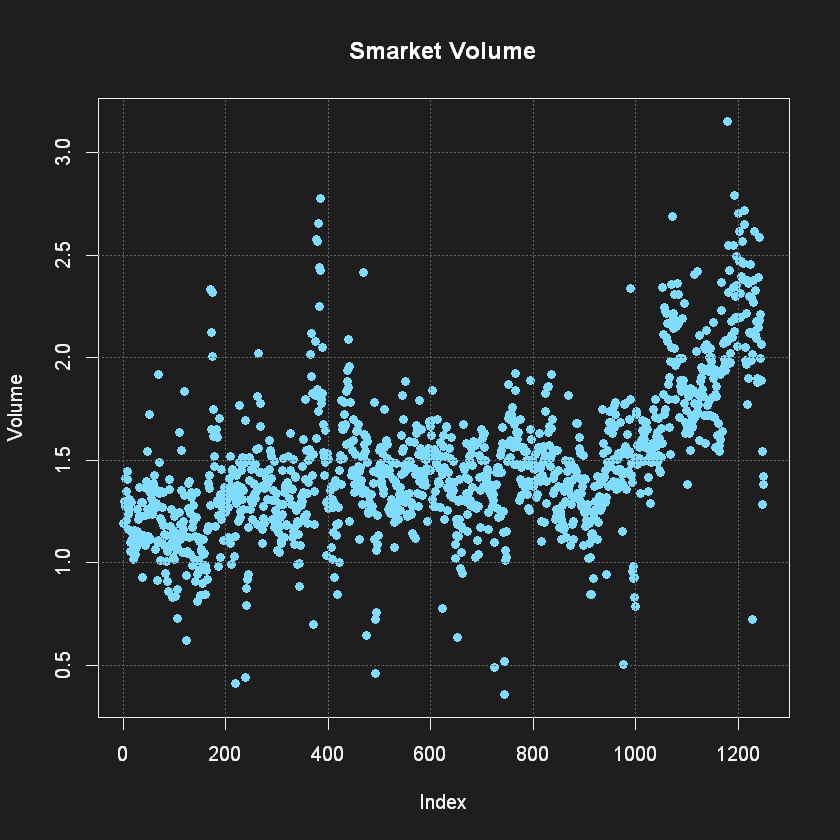

In [18]:
library(ISLR2)
# load library
names(Smarket)
# data set of stockmarket returns for S&P 500 stock index over 1,250 days
# lag1 - lag5 are % returns for 5 previous trading days
#Volume = no of shares traded on previous day
#Today = % return today or day in question
# Direction = whether the market was up or down
dim(Smarket)
#1250 (days) : 9(variables)
summary(Smarket)
cor(Smarket[,-9])
# The cor() function produces a matrix that contains all of the pairwise correlations among the predictors in a data set.You need the [] if var is qualitative
# shows only significant one is year and volume (as volume is inreasing over time and the other days have varied returns day by day)
attach(Smarket)

old_par <- par(no.readonly = TRUE)

par(
  bg = "#1e1e1e",        # plot background
  fg = "#f2f2f2",        # default text/axis color
  col.axis = "#f2f2f2",
  col.lab = "#f2f2f2",
  col.main = "#ffffff"
)

plot(
  Volume,
  col = "#7FDBFF",       # bright points/line
  pch = 19,
  main = "Smarket Volume"
)
grid(col = "#666666")
# Volume (millions) on Y and Index (each data point from 0 to 1250) on X

## 4.7.2 Logistic Regression

predict Direction using Lag1 through Lag5 and Volume

In [19]:
glm.fits <- glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, 
data = Smarket, family = binomial)
summary(glm.fits)
# The glm() function can be used to fit many types of generalized linear models, including logistic regression. The syntax of the glm() function is similar to that of lm(), except that we must pass in the argument family = binomial in order to tell R to run a logistic regression rather than some other type of generalized linear model.


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.126000   0.240736  -0.523    0.601
Lag1        -0.073074   0.050167  -1.457    0.145
Lag2        -0.042301   0.050086  -0.845    0.398
Lag3         0.011085   0.049939   0.222    0.824
Lag4         0.009359   0.049974   0.187    0.851
Lag5         0.010313   0.049511   0.208    0.835
Volume       0.135441   0.158360   0.855    0.392

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1731.2  on 1249  degrees of freedom
Residual deviance: 1727.6  on 1243  degrees of freedom
AIC: 1741.6

Number of Fisher Scoring iterations: 3


In [20]:
#The smallest p-value here is associated with Lag1. The negative coefficient for this predictor suggests that if the market had a positive return yesterday,then it is less likely to go up today. However, at a value of 0.15, the p-value is still relatively large, and so there is no clear evidence of a real associationbetween Lag1 and Direction.

# access coefficients for the fitted model
coef(glm.fits)

(Intercept)         Lag1         Lag2         Lag3         Lag4         Lag5 
-0.126000257 -0.073073746 -0.042301344  0.011085108  0.009358938  0.010313068 
      Volume 
 0.135440659

In [21]:
# we can be specific with the summary() function to get the coefficients and p-values
summary(glm.fits)$coef
# the 4th column of the coefficient matrix contains the p-values
summary(glm.fits)$coef[,4]

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-0.126000257,0.24073574,-0.5233966,0.6006983
Lag1,-0.073073746,0.05016739,-1.4565986,0.1452272
Lag2,-0.042301344,0.05008605,-0.8445733,0.3983491
Lag3,0.011085108,0.04993854,0.2219750,0.8243333
Lag4,0.009358938,0.04997413,0.1872757,0.8514445
Lag5,0.010313068,0.04951146,0.2082966,0.8349974
Volume,0.135440659,0.15835970,0.8552723,0.3924004


(Intercept)        Lag1        Lag2        Lag3        Lag4        Lag5 
  0.6006983   0.1452272   0.3983491   0.8243333   0.8514445   0.8349974 
     Volume 
  0.3924004

In [22]:
#predict probabilities of the market going up
#type = "response" gives us the probabilities P(Y=1|X) of the market going up
glm.probs <- predict(glm.fits, type = "response")
round(glm.probs[1:10], 3)
#round 3 to 3 decimal places

1     2     3     4     5     6     7     8     9    10 
0.507 0.481 0.481 0.515 0.511 0.507 0.493 0.509 0.518 0.489

In [23]:
contrasts(Direction)
#shows probabilities of the market going up rather than down as 1 is set to up

,Up
Down,0
Up,1


In [24]:
#The following two commands create a vector of class predictions based on whether the predicted probability of a market increase is greater than or less than 0.5.
glm.pred <- rep("Down", 1250)
glm.pred[glm.probs > .5] <- "Up"
table(glm.pred, Direction)

        Direction
glm.pred Down  Up
    Down  145 141
    Up    457 507

In [25]:
# 145 = predicted Down & actual Down = match
# 141 = predicted Down & actual Up = mismatch
# 457 = predicted Up & actual Down = mismatch
# 507 = predicted Up & actual Up = match

#therefore 507+145 = 652 correct predictions out of 1250 total observations
(507+145)/1250

mean(glm.pred == Direction)
#(gets the same result - 52.2% accuracy)

[1] 0.5216

[1] 0.5216

In [26]:
# Split data: train on years before 2005, test on 2005
train <- (Year < 2005)

# Keep only the 2005 rows (this is the test set)
Smarket.2005 <- Smarket[!train,]

# Check size of test set (should be 252 rows)
dim(Smarket.2005)

# Actual (true) labels for 2005
Direction.2005 <- Direction[!train]

# Fit model using only training rows (before 2005)
glm.fits <- glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, 
data = Smarket, family = binomial, subset = train)

# Predict probability of Up for each 2005 day
glm.probs <- predict(glm.fits, Smarket.2005, type = "response")

# Start by predicting Down for every 2005 day
glm.pred <- rep("Down", 252)

# If probability > 0.5, change prediction to Up
glm.pred[glm.probs > .5] <- "Up"

# Compare predicted vs actual (confusion matrix)
table(glm.pred, Direction.2005)

[1] 252   9

        Direction.2005
glm.pred Down Up
    Down   77 97
    Up     34 44

In [27]:
mean(glm.pred == Direction.2005)
# the % right predictions is 48.4% e.g the accuracy
mean(glm.pred != Direction.2005)
# the % wrong predictions is 51.6% e.g the error rate 

[1] 0.4801587

[1] 0.5198413

In [28]:
# the model performs worse than random guessing (which would be 50% accuracy) on the test data, even though it performed slightly better than random guessing on the training data. This is an example of overfitting, where a model fits the training data well but fails to generalize to new data.
# Using predictors that have no relationship with the response tends to cause a deterioration in the test error rate (since such predictors cause an increase in variance without a corresponding decrease in bias). So lets remove them.

glm.fits <- glm(Direction ~ Lag1 + Lag2, data = Smarket, family = binomial, subset = train)
#lag1 and lag2 are the only predictors with p-values less than 0.15, so we will refit the logistic regression model using only these two predictors.

glm.probs <- predict(glm.fits, Smarket.2005, type = "response")
glm.pred <- rep("Down", 252)
glm.pred[glm.probs > .5] <- "Up"
table(glm.pred, Direction.2005)


        Direction.2005
glm.pred Down  Up
    Down   35  35
    Up     76 106

In [29]:
mean(glm.pred == Direction.2005)
#yeilds 56.0% accuracy, which is better than the previous model and random guessing

[1] 0.5595238

In [30]:
106/(106+76)
# taken from the up predictions, yeilds a similar result of 58.3% accuracy, which is better than the previous model and random guessing and would suggest that the model is better at predicting when the market will go up than when it will go down, but this could be chance.

[1] 0.5824176

In [32]:
#lets predict some exact values, say lag1 at 1.2 and lag2 at 1.1, which are the values for the first row of the data set
predict(glm.fits, newdata = data.frame(Lag1 = 1.2, Lag2 = 1.1), type = "response")

predict(glm.fits, newdata = data.frame(Lag1 = 1.5, Lag2 = -0.8), type = "response")

#also can be written altogether as
predict(glm.fits, newdata = data.frame(Lag1 = c(1.2, 1.5), Lag2 = c(1.1, -0.8)), type = "response")

1 
0.4791462

1 
0.4960939

1         2 
0.4791462 0.4960939

## 4.7.3 Linear Discriminant Analysis

In [33]:
# lda(), part of the MASS library, is identical to the lm() function and glm() without the family option
# again we'll fit using obsrv before 2005 and test on 2005

library(MASS)
lda.fit <- lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)
lda.fit



Attaching package: 'MASS'


The following object is masked from 'package:ISLR2':

    Boston




Call:
lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

Coefficients of linear discriminants:
            LD1
Lag1 -0.6420190
Lag2 -0.5135293

In [35]:
#indicates that ˆπ1 = 0.492 and ˆπ2 = 0.508; in other words, 49.2 % of the training observations correspond to days during which the market went down
#ˆπ1 and ˆπ2 are the prior probabilities of class.
# there is a tendency for the previous 2 days’ returns to be negative on days when the market increases, and a tendency for the previous days’ returns to be positive on days when the market declines

#for LD1
#If −0.642×Lag1 − 0.514×Lag2 is large, then the LDA classifier will predict a market increase, and if it is small, then the LDA classifier will predict a market decline.

lda.pred <- predict(lda.fit, Smarket.2005)
names(lda.pred)

[1] "class"     "posterior" "x"

In [36]:
#'class' contains the LDA predictions for each observation in the test set
#'posterior' contains the posterior probabilities for each class, in a matrix with two columns, one for each class
#'x' contains the linear discriminants for each observation

lda.class <- lda.pred$class
table(lda.class, Direction.2005)

         Direction.2005
lda.class Down  Up
     Down   35  35
     Up     76 106

In [ ]:
# almost identical to the logistic regression model:
#        Direction.2005
#glm.pred Down  Up
#    Down   35  35
#    Up     76 106

#apply a 50% threshold to the posterior probabilities to produce class predictions
sum(lda.pred$posterior[,1] >= 0.5) #70 observations are predicted "Down"
sum(lda.pred$posterior[,1] < 0.5) # 182 observations are predicted "Up"

# 70 : 182 ratio is demonstrated here:
lda.pred$posterior[1:20,1]
lda.class[1:20]

[1] 70

[1] 182

999      1000      1001      1002      1003      1004      1005      1006 
0.4901792 0.4792185 0.4668185 0.4740011 0.4927877 0.4938562 0.4951016 0.4872861 
     1007      1008      1009      1010      1011      1012      1013      1014 
0.4907013 0.4844026 0.4906963 0.5119988 0.4895152 0.4706761 0.4744593 0.4799583 
     1015      1016      1017      1018 
0.4935775 0.5030894 0.4978806 0.4886331

[1] Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Down Up   Up   Up  
[16] Up   Up   Down Up   Up  
Levels: Down Up

In [ ]:
# lets try a 90% threshold instead of 50%
sum(lda.pred$posterior[,1] >= 0.9) # gets 0 therefore no days in 2005 meet the threshold

[1] 0

## 4.7.4 Quadratic Disriminant Analysis